#### **Data Loading**

In [72]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [42]:
ds = load_dataset("shree0910/AI-and-Data-Science-Job-Market-Dataset")

In [44]:
df = ds['train'].to_pandas()

In [45]:
df.head(5)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

In [47]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [50]:
num_cols = df.select_dtypes(include=['int64']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['int64']).columns.tolist()

print(num_cols)
print(cat_cols)

['job_id', 'years_experience', 'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month', 'job_posting_year', 'job_openings']
['job_title', 'company_size', 'company_industry', 'country', 'remote_type', 'experience_level', 'education_level', 'hiring_urgency']


#### **Feature Engineering**

In [78]:
def uni_num(df, cols):
  n_cols = 3
  n_rows = -(-len(cols) // n_cols)
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
  axes = axes.flatten()

  for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i], kde=False, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

  for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

  plt.tight_layout()
  plt.show()

In [79]:
cols_to_drop = ['job_id']
skill_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
time_cols = ['job_posting_month', 'job_posting_year']

num_cols = [c for c in num_cols 
                  if c not in cols_to_drop + skill_cols + time_cols]

cat_cols = cat_cols + skill_cols + time_cols

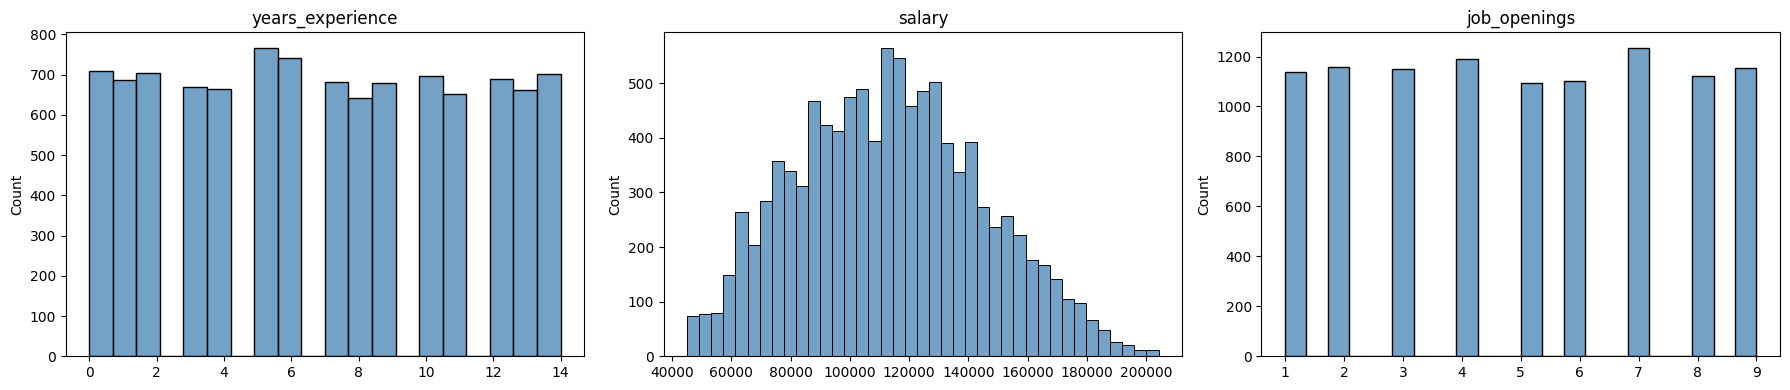

In [80]:
uni_num(df, num_cols)

In [53]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower bound: {lower:,.0f}")
print(f"Upper bound: {upper:,.0f}")
print(f"Outliers: {((df['salary'] < lower) | (df['salary'] > upper)).sum()}")

Lower bound: 21,946
Upper bound: 202,662
Outliers: 4


In [54]:
outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]
print(outliers[['job_title', 'experience_level', 'company_size', 'salary']])

                      job_title experience_level company_size  salary
254                 AI Engineer           Senior          MNC  203662
1471                AI Engineer           Senior          MNC  203450
3066  Machine Learning Engineer           Senior          MNC  203738
6695  Machine Learning Engineer           Senior          MNC  204143


#### **Business Questions & Bivariate**

Q1: Which job titles are most open to entry-level candidates?

In [55]:
df[df['experience_level'] == 'Entry'] \
  .groupby('job_title') \
  .size() \
  .sort_values(ascending=False)

job_title
Machine Learning Engineer    603
AI Engineer                  601
Data Engineer                583
Data Analyst                 582
Business Analyst             578
Data Scientist               566
dtype: int64

Q2: Do larger companies offer more remote opportunities?

In [56]:
remoteBySize = df[df['remote_type'] == 'Remote'] \
  .groupby('company_size') \
  .size() \
  .sort_values(ascending=False)

print(remoteBySize)

company_size
Startup       918
MNC           888
Medium        863
Enterprise    844
dtype: int64


Q2.1: Which job titles have the highest remote availability?

In [57]:
df[df['remote_type'] == 'Remote'] \
  .groupby('job_title') \
  .size() \
  .sort_values(ascending=False)

job_title
AI Engineer                  606
Business Analyst             597
Machine Learning Engineer    590
Data Engineer                580
Data Scientist               579
Data Analyst                 561
dtype: int64

Q3: Which industries are actively hiring candidates with a Bachelor's degree and no prior experience? (On %)

In [59]:
# Total jobs per industry (all levels)
total_by_industry = df.groupby('company_industry').size()

# Entry level per industry
entry_by_industry = df[(df['education_level'] == 'Bachelor') & 
                       (df['experience_level'] == 'Entry')] \
                   .groupby('company_industry').size()

# % entry level per industry
pct = (entry_by_industry / total_by_industry * 100).sort_values(ascending=False)
print(pct.round(1))

company_industry
E-commerce    12.4
Healthcare    11.4
Technology    11.0
Education     10.7
Retail        10.1
Finance       10.0
dtype: float64


Q4: How does salary vary across job titles, experience levels, and company sizes?

In [62]:
salary_entry = df[(df['education_level'] == 'Bachelor') & (df['experience_level'] == 'Entry')] \
  .groupby('company_industry')['salary'].median() \
  .sort_values(ascending=False)

print(salary_entry.round(0))  

company_industry
E-commerce    90695.0
Finance       87894.0
Retail        84630.0
Education     83998.0
Healthcare    83994.0
Technology    83518.0
Name: salary, dtype: float64


C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2614484117.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entry_by_role.values, y=entry_by_role.index,
C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2614484117.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=remote_by_size.index, y=remote_by_size.values,
C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2614484117.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.values, y=pct.index,
C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2614484117.py:47: FutureWarni

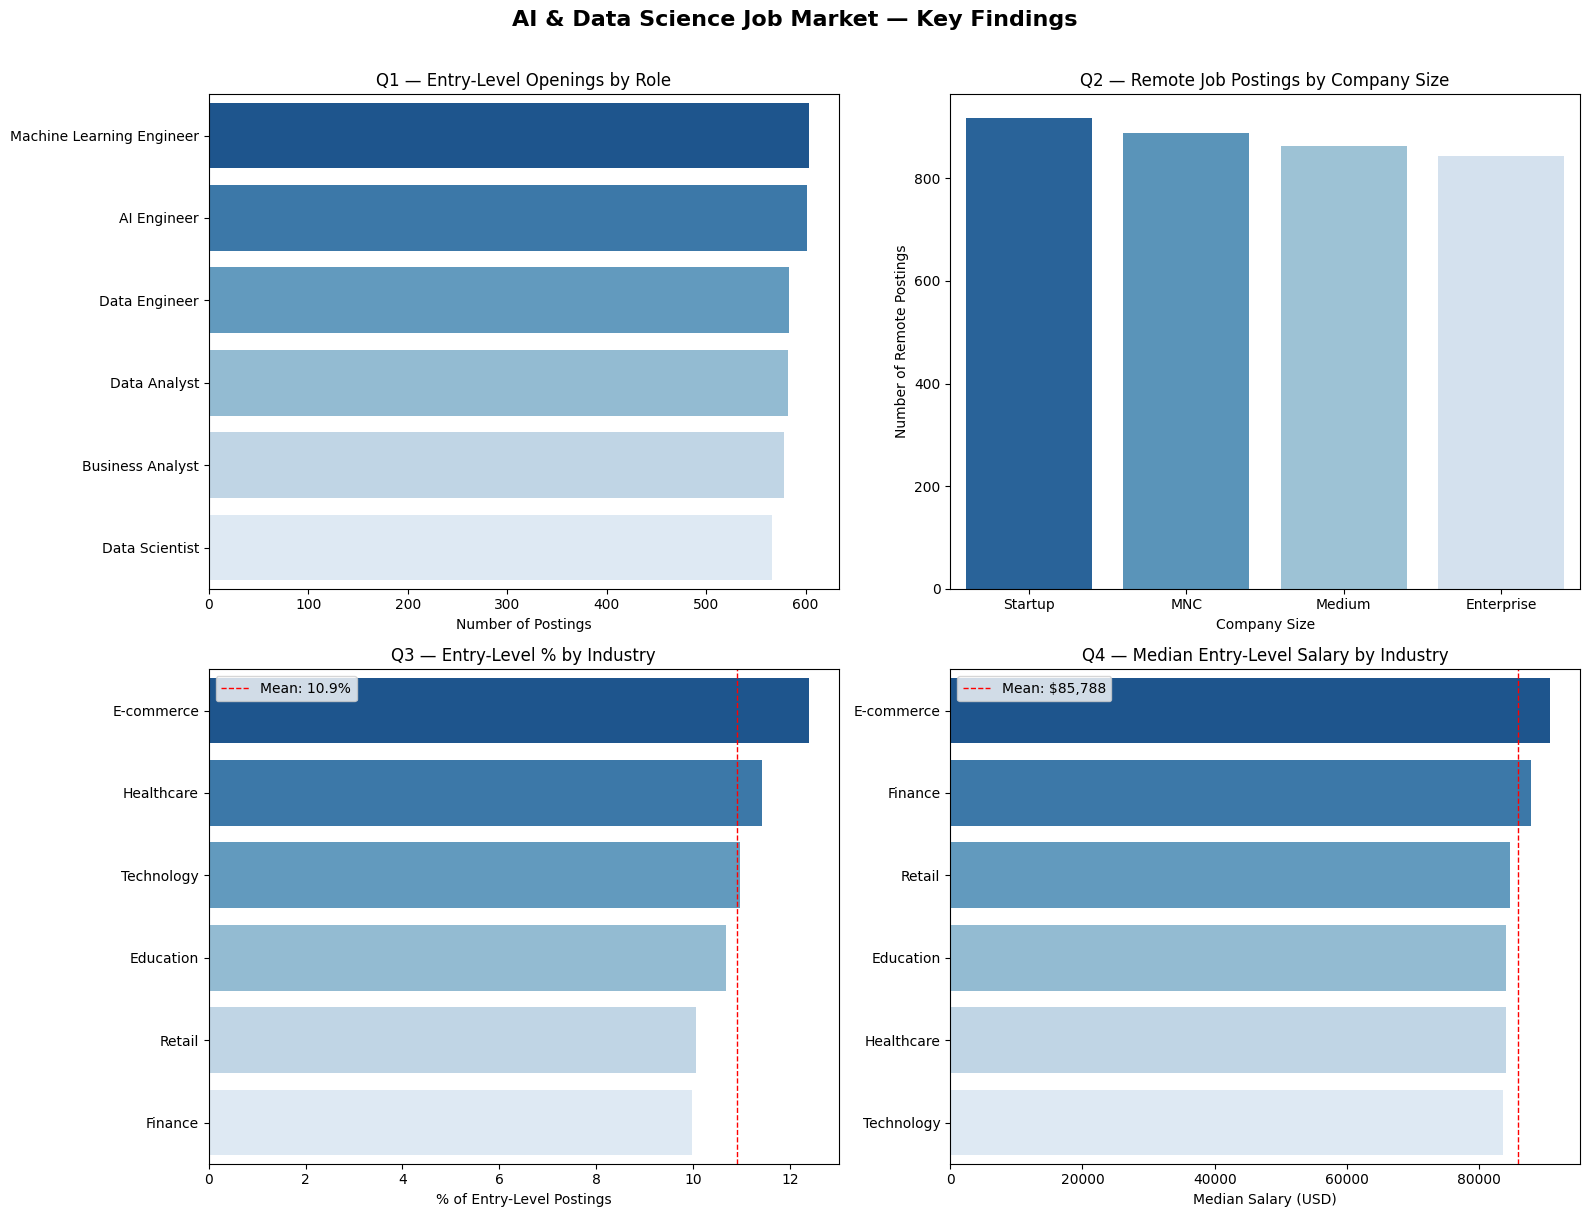

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AI & Data Science Job Market — Key Findings', 
             fontsize=16, fontweight='bold', y=1.01)

# Q1: Entry-level openings by role
entry_by_role = df[df['experience_level'] == 'Entry'] \
    .groupby('job_title').size().sort_values(ascending=False)

sns.barplot(x=entry_by_role.values, y=entry_by_role.index,
            palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Q1 — Entry-Level Openings by Role')
axes[0, 0].set_xlabel('Number of Postings')
axes[0, 0].set_ylabel('')

# Q2: Remote availability by company size
remote_by_size = df[df['remote_type'] == 'Remote'] \
    .groupby('company_size').size().sort_values(ascending=False)

sns.barplot(x=remote_by_size.index, y=remote_by_size.values,
            palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title('Q2 — Remote Job Postings by Company Size')
axes[0, 1].set_xlabel('Company Size')
axes[0, 1].set_ylabel('Number of Remote Postings')

# Q3: Entry-level acceptance rate by industry (%)
total_by_industry = df.groupby('company_industry').size()
entry_by_industry = df[(df['education_level'] == 'Bachelor') &
                       (df['experience_level'] == 'Entry')] \
                   .groupby('company_industry').size()
pct = (entry_by_industry / total_by_industry * 100).sort_values(ascending=False)

sns.barplot(x=pct.values, y=pct.index,
            palette='Blues_r', ax=axes[1, 0])
axes[1, 0].set_title('Q3 — Entry-Level % by Industry')
axes[1, 0].set_xlabel('% of Entry-Level Postings')
axes[1, 0].set_ylabel('')
axes[1, 0].axvline(x=pct.mean(), color='red', 
                    linestyle='--', linewidth=1, label=f'Mean: {pct.mean():.1f}%')
axes[1, 0].legend()

# Q4: Median salary (entry-level) by industry
salary_entry = df[(df['education_level'] == 'Bachelor') &
                  (df['experience_level'] == 'Entry')] \
              .groupby('company_industry')['salary'].median() \
              .sort_values(ascending=False)

sns.barplot(x=salary_entry.values, y=salary_entry.index,
            palette='Blues_r', ax=axes[1, 1])
axes[1, 1].set_title('Q4 — Median Entry-Level Salary by Industry')
axes[1, 1].set_xlabel('Median Salary (USD)')
axes[1, 1].set_ylabel('')
axes[1, 1].axvline(x=salary_entry.mean(), color='red',
                    linestyle='--', linewidth=1, 
                    label=f'Mean: ${salary_entry.mean():,.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Key Findings

**Q1: Entry-Level Openings by Role**  
All data roles show comparable entry-level availability (~566–603 postings), 
with ML Engineer and AI Engineer slightly leading.  
*Conclusion: No single role is significantly easier to break into than others.*

**Q2: Remote by Company Size**  
Remote opportunities are evenly distributed across company sizes, 
Startups lead marginally (918), but the gap to Enterprise (844) is only ~8%.  
*Conclusion: Don't limit your remote job search to large companies.*

**Q3: Entry-Level % by Industry**  
All industries allocate roughly 10–12% of postings to entry-level Bachelor candidates.  
E-commerce leads (12.4%), Finance trails (10.0%) but the difference is minimal.  
*Conclusion: Industry choice matters less than expected for entry-level access.*

**Q4: Median Entry-Level Salary by Industry**  
E-commerce offers the highest median entry salary ($90.7k), 
Technology the lowest ($83.5k) — a ~8% gap across industries.  
*Conclusion: E-commerce is the sweet spot, highest acceptance rate & highest salary.*

C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2431930505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')


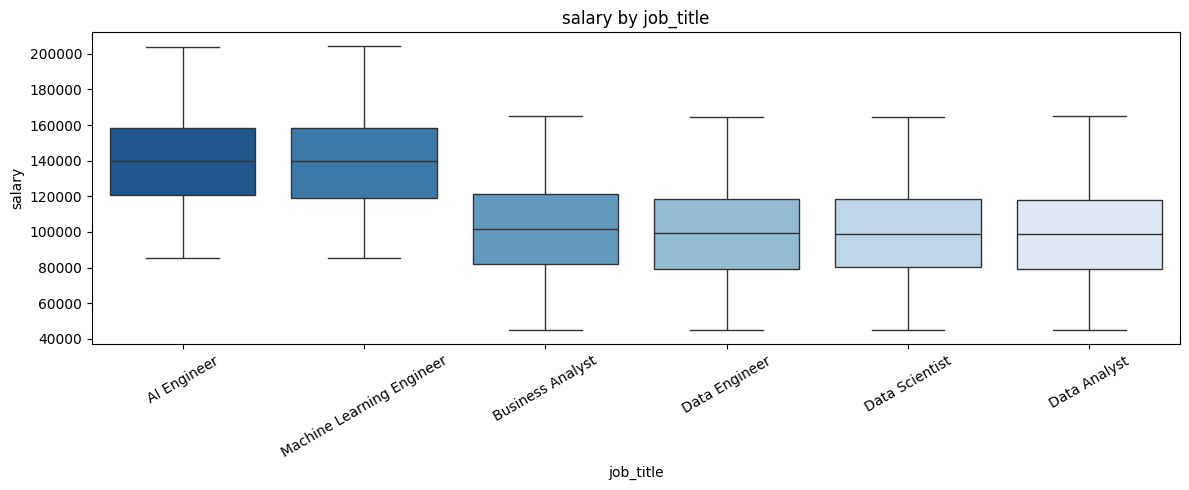

C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2431930505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')


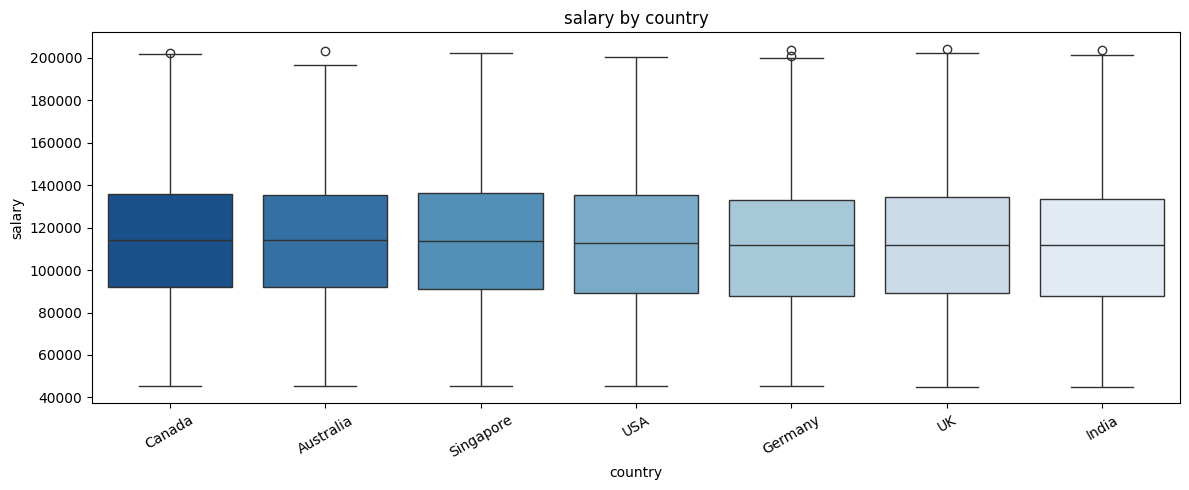

C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2431930505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')


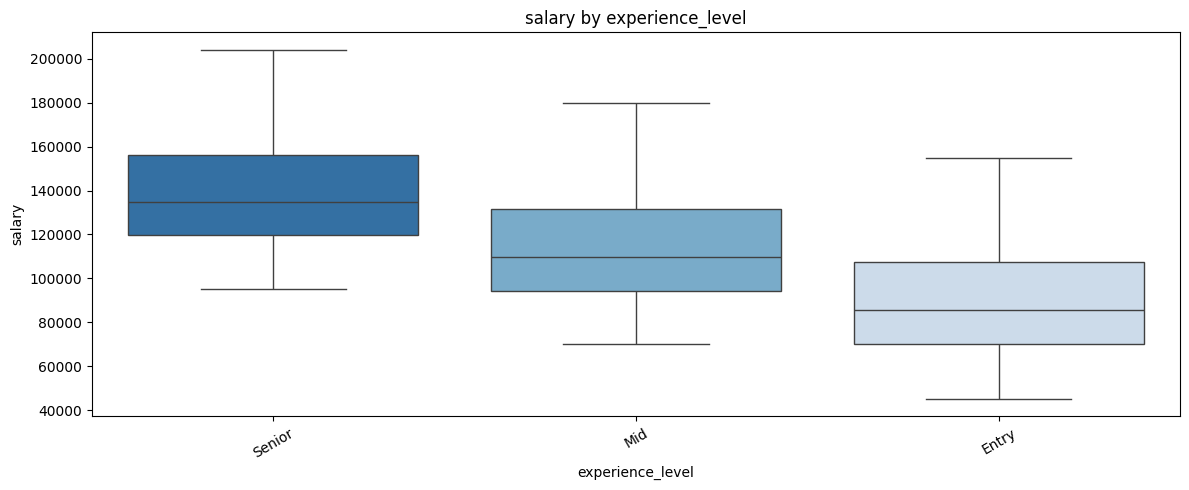

C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2431930505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')


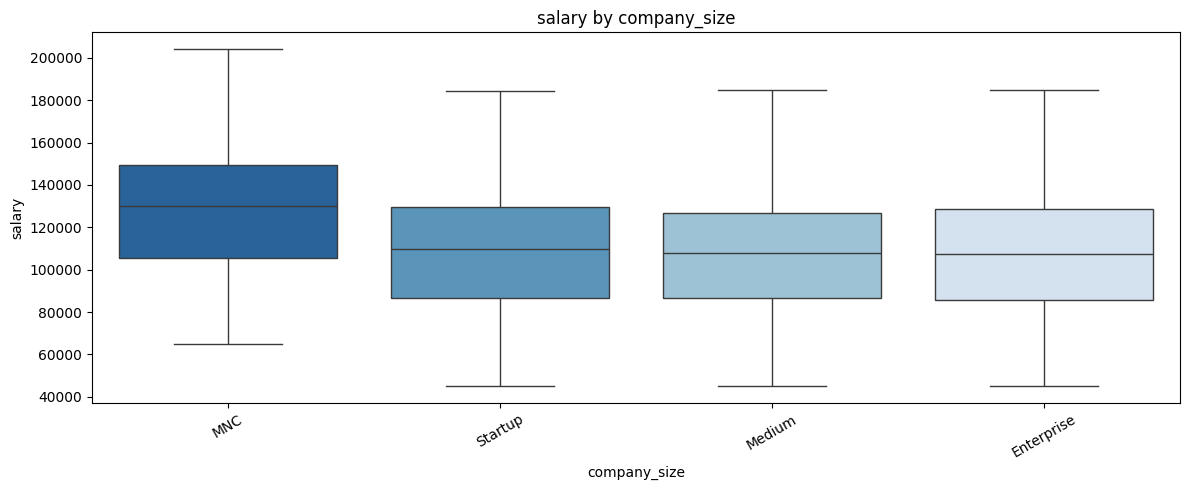

C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\2431930505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')


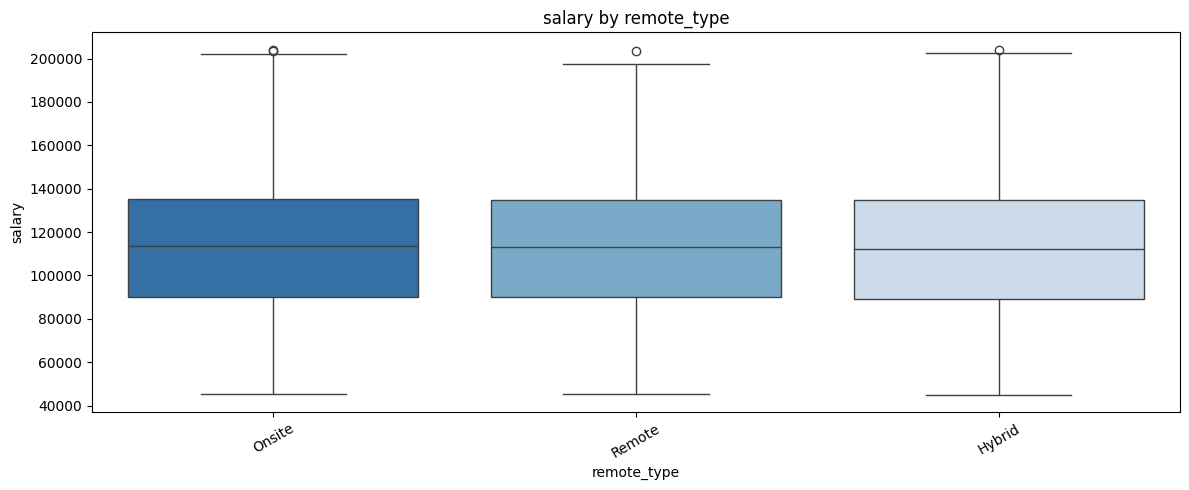

In [66]:
def bivariate_cat_vs_num(df, cat_col, num_col):
    order = df.groupby(cat_col)[num_col].median().sort_values(ascending=False).index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df, x=cat_col, y=num_col, order=order, palette='Blues_r')
    plt.title(f'{num_col} by {cat_col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

bivariate_cat_vs_num(df, 'job_title', 'salary')
bivariate_cat_vs_num(df, 'country', 'salary')
bivariate_cat_vs_num(df, 'experience_level', 'salary')
bivariate_cat_vs_num(df, 'company_size', 'salary')
bivariate_cat_vs_num(df, 'remote_type', 'salary')

### Bivariate Analysis — Salary Drivers

**- Job Title:** AI Engineer and ML Engineer command significantly higher salaries 
(median ~$140k) compared to Data Analyst and Data Scientist (~$100k), 
a ~40% gap suggesting specialization in AI/ML is financially rewarded.

**- Country:** Median salaries are nearly identical across all 7 countries (~$110k), 
which is unrealistic for real-world data. This strongly suggests the dataset 
is synthetically generated, limiting geographic salary insights.

**- Experience Level:** The clearest signal — Senior (~$135k) earns roughly 60% 
more than Entry level (~$83k), confirming experience as the strongest salary driver.

**- Company Size:** MNC offers the highest median salary with the widest IQR, 
indicating greater variability, likely mixing junior and senior roles across divisions.

**- Remote Type:** No meaningful salary difference across Onsite, Remote, and Hybrid.
Remote work does not appear to carry a salary premium in this dataset.

#### ML

In [ ]:
# new feature
df['total_skills'] = df[skill_cols].sum(axis=1)
print(df['total_skills'].value_counts().sort_index())

total_skills
0     290
1    1662
2    3186
3    3201
4    1665
5     341
Name: count, dtype: int64


In [ ]:
df_model = df.copy()

cat_to_encode = ['job_title', 'company_size', 'company_industry',
                 'country', 'remote_type', 'experience_level',
                 'education_level', 'hiring_urgency']

le = LabelEncoder()
for col in cat_to_encode:
    df_model[col] = le.fit_transform(df_model[col])

print(df_model.head(3))

   job_id  job_title  company_size  company_industry  country  remote_type  \
0       1          0             3                 4        1            2   
1       2          5             1                 5        0            0   
2       3          5             1                 5        2            1   

   experience_level  years_experience  education_level  skills_python  \
0                 2                 2                1              0   
1                 1                 0                0              1   
2                 1                14                1              1   

   skills_sql  skills_ml  skills_deep_learning  skills_cloud  salary  \
0           0          0                     1             0  158322   
1           1          1                     0             1  163666   
2           0          1                     0             1  158556   

   job_posting_month  job_posting_year  hiring_urgency  job_openings  \
0                  6             

In [ ]:
low = df['salary'].quantile(0.33)
high = df['salary'].quantile(0.67)

df_model['salary_tier'] = pd.cut(df['salary'],
                                  bins=[0, low, high, 999999],
                                  labels=['Low', 'Mid', 'High'])

# Salary tiers defined by 33rd and 67th percentile (to create balanced class distribution esp for 3 groups)

print(df_model['salary_tier'].value_counts())

salary_tier
Mid     3517
Low     3414
High    3414
Name: count, dtype: int64


In [69]:
X = df_model.drop(columns=['salary', 'salary_tier'])
y = df_model['salary_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

        High       0.92      0.92      0.92       683
         Low       0.97      0.94      0.96       683
         Mid       0.87      0.89      0.88       703

    accuracy                           0.92      2069
   macro avg       0.92      0.92      0.92      2069
weighted avg       0.92      0.92      0.92      2069



In [70]:
# feature importance
feat_imp = pd.Series(rf.feature_importances_, 
                     index=X.columns) \
             .sort_values(ascending=False)

print(feat_imp)

experience_level        0.263144
job_title               0.236382
company_size            0.067473
years_experience        0.046149
job_posting_month       0.043623
job_openings            0.037736
total_skills            0.037102
country                 0.036116
job_posting_year        0.035946
company_industry        0.033043
skills_deep_learning    0.030607
skills_ml               0.029856
remote_type             0.020313
education_level         0.020263
skills_cloud            0.019692
hiring_urgency          0.018952
skills_sql              0.012133
skills_python           0.011471
dtype: float64


C:\Users\Kalila\AppData\Local\Temp\ipykernel_42644\548069803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')


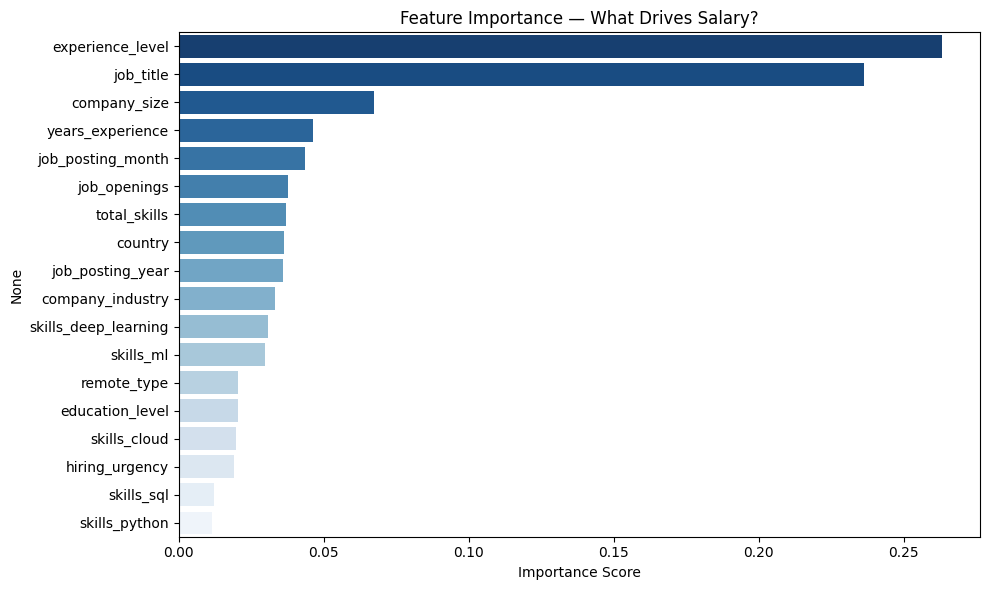

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Feature Importance — What Drives Salary?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### ML Findings — What Drives Salary?

Random Forest Classifier achieved **92% accuracy** on balanced salary tiers (Low/Mid/High).

**Key insight:** `experience_level` and `job_title` together account for ~50% of 
prediction importance, dwarfing all other features including skills.  
*Individual skills (Python, SQL) rank at the bottom, suggesting role and seniority 
matter far more than tool stack when it comes to salary.*

**Note:** `job_posting_month` appearing in top features (rank 5) is likely an artifact 
of synthetic data generation, not a real-world signal.